# Lab: Comparing Distributions Across Groups

New York City residents can use 311 to report potholes, cave-ins, failed street repairs, and other street conditions. Comparing the daily volume of these requests can help a city describe where reported demand for street-condition services was greatest.

Use the reproducible analysis workflow:

1. **Question**
2. **Data**
3. **Operation**
4. **Check**
5. **Evidence**
6. **Conclusion**
7. **Limitation**


## Learning goals

- use Pandas datetime and string methods to prepare categories;
- use `groupby()`, `.size()`, and `reset_index()` to create daily counts;
- summarize a quantitative feature within groups;
- compare distributions with histograms, box plots, and violin plots;
- interpret center, spread, shape, overlap, and unusual values; and
- distinguish reported request volume from the underlying number of street problems.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

The teaching file contains NYC 311 service requests created during 2025 with the complaint type `Street Condition`. Rows assigned to an unspecified borough were excluded. Each row represents one service request, not one unique street problem.

| Feature | Description |
| --- | --- |
| `request_id` | Identifier assigned to the 311 service request |
| `created_date` | Date and time when 311 created the request |
| `borough` | Borough assigned to the request |
| `descriptor` | More specific kind of street condition |

The file was downloaded from NYC Open Data on August 13, 2026. See `data/README.md` for provenance and preparation details.


# Guided analysis

## Step 1: Question

> **How did the daily number of reported street-condition requests differ across New York City's five boroughs in 2025?**


## Step 2: Data

### Import the libraries

Import Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.


In [1]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Read the data

Read `data/nyc_311_street_conditions_2025.csv` into a DataFrame named `requests`. Use `parse_dates=["created_date"]` so Pandas converts the CSV's text timestamps into datetime values while loading the file.


In [2]:
# Write your code here.
requests = pd.read_csv("data/nyc_311_street_conditions_2025.csv", parse_dates=["created_date"])

### Preview the data

Display the first and last five rows.


In [3]:
# Write your code here.
requests


,request_id,created_date,borough,descriptor
0,63575321,2025-01-01 02:27:33,BROOKLYN,Pothole
1,63585580,2025-01-01 02:31:08,QUEENS,Pothole
2,63590681,2025-01-01 02:39:44,BROOKLYN,Dumpster - Construction Waste
3,63580421,2025-01-01 02:55:52,QUEENS,Pothole
4,63605103,2025-01-01 04:20:00,BROOKLYN,Wear & Tear
...,...,...,...,...
70193,67353473,2025-12-31 22:26:49,STATEN ISLAND,Pothole
70194,67346881,2025-12-31 22:27:34,STATEN ISLAND,Pothole
70195,67352385,2025-12-31 22:28:43,STATEN ISLAND,Cave-in
70196,67350032,2025-12-31 22:53:19,MANHATTAN,Defective Hardware


### Inspect the DataFrame

Display its stored data types and missing-value counts.


In [4]:
# Write your code here.
requests.info()

<class 'pandas.DataFrame'>
RangeIndex: 70198 entries, 0 to 70197
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   request_id    70198 non-null  int64         
 1   created_date  70198 non-null  datetime64[us]
 2   borough       70198 non-null  str           
 3   descriptor    70198 non-null  str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 3.4 MB


In [5]:
requests.isnull().sum()

request_id      0
created_date    0
borough         0
descriptor      0
dtype: int64

In [6]:
requests["borough"].value_counts()

borough
QUEENS           25981
BROOKLYN         18376
MANHATTAN        12387
BRONX             6957
STATEN ISLAND     6497
Name: count, dtype: int64

**Complete the table using the data dictionary and your inspection results.** Classify each feature as categorical, quantitative, or temporal.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `request_id` | quantitative | int64 | 0 |
| `created_date` | temporal | datetime64 | 0 |
| `borough` | categorical | string | 0 |
| `descriptor` | categorical | string | 0 |


**What does one row represent?**

Your answer:
one NYC 311 service request created during 2025 with the complaint type Street Condition


### Predict


**Which borough do you predict will have the greatest typical number of reported street-condition requests per day? What informed your prediction?**

Your answer: I predict Queens will have the greatest typical number of reported requests per day. I came to this conclusion because Queens has the highest total number of reports.


## Step 3: Operation


### Make the borough names human-readable

The source stores borough names in all capital letters. **Title case** capitalizes the first letter of each word and writes the remaining letters in lowercase. For example, `STATEN ISLAND` becomes `Staten Island`.

Use `.str.title()` to convert every value in `requests["borough"]` to title case and save the result back into the same feature.


In [7]:
# Write your code here.
requests['borough'] = requests["borough"].str.title()
requests["borough"].value_counts()

borough
Queens           25981
Brooklyn         18376
Manhattan        12387
Bronx             6957
Staten Island     6497
Name: count, dtype: int64

**What roles do `.str` and `.title()` play in this statement?**

Your answer: .str returns the string value held in each row's borough column, then .title() converts the value into Title Case.


### Create a calendar date

Create `requests["date"]` with `requests["created_date"].dt.normalize()`. The `.dt` accessor opens Pandas' datetime tools, and `.normalize()` sets the time in every value to midnight while preserving its calendar date.


In [8]:
# Write your code here.
requests["date"] = requests["created_date"].dt.normalize()
requests[["date", "created_date"]].head()

,date,created_date
0,2025-01-01,2025-01-01 02:27:33
1,2025-01-01,2025-01-01 02:31:08
2,2025-01-01,2025-01-01 02:39:44
3,2025-01-01,2025-01-01 02:55:52
4,2025-01-01,2025-01-01 04:20:00


### Count requests for each borough and date

Create a DataFrame named `daily_requests` with this sequence:

1. group `requests` by `date` and `borough`;
2. use `.size()` to count rows in every group; and
3. use `.reset_index(name="request_count")` to return a DataFrame whose count column is named `request_count`.

Display the first five rows.


In [9]:
# Write your code here.
daily_requests = requests.groupby(["borough", "date"]).size().reset_index(name="request_count")
daily_requests

,borough,date,request_count
0,Bronx,2025-01-01,33
1,Bronx,2025-01-02,5
2,Bronx,2025-01-03,8
3,Bronx,2025-01-04,22
4,Bronx,2025-01-05,19
...,...,...,...
1820,Staten Island,2025-12-27,3
1821,Staten Island,2025-12-28,21
1822,Staten Island,2025-12-29,19
1823,Staten Island,2025-12-30,26


**What does one row of `daily_requests` represent? How is that different from one row of `requests`?**

Your answer: One row of `daily_requests` is the total number of requests made on a specific day in the borough. One row of `requests` represents one singular request.


**Why did we remove the time before grouping and counting the requests?** As a hint, try repeating the calculation with `created_date` in place of `date` and inspect the result.

Your answer: If we did not remove the time, the request counts would be the number of request made on a specific date AND time


### Set the borough order

Create `borough_order` containing the five borough names in alphabetical order.


In [10]:
# Write your code here.
# References
#QUEENS           25981
#BROOKLYN         18376
#MANHATTAN        12387
#BRONX             6957
#STATEN ISLAND     6497
borough_order = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
daily_requests["borough"].count() - daily_requests["borough"].isin(borough_order).sum()  # making sure all boroughs are added

np.int64(0)

### Calculate the mean daily request count

Create `borough_summary` by grouping `daily_requests` by `borough`, selecting `request_count`, calculating the mean, and using `.reindex(borough_order)`.


In [11]:
# Write your code here.
borough_summary = daily_requests.groupby("borough")["request_count"].mean().reindex(borough_order)
borough_summary


borough
Bronx            19.060274
Brooklyn         50.345205
Manhattan        33.936986
Queens           71.180822
Staten Island    17.800000
Name: request_count, dtype: float64

**Why is comparing only these means incomplete?**

Your answer:


## Step 4: Check


### Check borough-date coverage

Count the number of rows for each borough in `daily_requests`, then use `.reindex(borough_order)`.


In [12]:
# Write your code here.
daily_requests.groupby('borough')['date'].nunique().reindex(borough_order)

borough
Bronx            365
Brooklyn         365
Manhattan        365
Queens           365
Staten Island    365
Name: date, dtype: int64

**Does every borough have a count for all 365 dates?**

Your answer: Yes


**What would it mean if one or more boroughs had a count of fewer than 365 rows?**

Your answer: There was a day where no requests were made.


### Check the calculated data

Display missing-value counts for `date`, `borough`, and `request_count`. Then use `.describe()` to summarize `request_count` within each borough and put the boroughs in `borough_order`.


In [13]:
# Write your code here.
daily_requests[["date", "borough", "request_count"]].isna().sum()


date             0
borough          0
request_count    0
dtype: int64

In [14]:
daily_requests[["borough", "request_count"]].groupby("borough").describe().reindex(borough_order)

request_count                                                \
                      count       mean        std   min   25%   50%   75%   
borough                                                                     
Bronx                 365.0  19.060274   9.238398   1.0  12.0  18.0  25.0   
Brooklyn              365.0  50.345205  21.132529   6.0  33.0  51.0  65.0   
Manhattan             365.0  33.936986  14.683432   2.0  23.0  33.0  43.0   
Queens                365.0  71.180822  30.362103  11.0  47.0  70.0  89.0   
Staten Island         365.0  17.800000  10.095206   1.0  10.0  17.0  24.0   

                      
                 max  
borough               
Bronx           48.0  
Brooklyn       113.0  
Manhattan       91.0  
Queens         215.0  
Staten Island   66.0

**Are any calculated values missing or impossible?**

Your answer: No



**Would a zero necessarily be impossible in another 311 dataset?**

Your answer: No


## Step 5: Evidence


### Create overlapping histograms

Use `sns.histplot()` with:

- `data=daily_requests`;
- `x="request_count"`;
- `hue="borough"` and `hue_order=borough_order`;
- `element="step"`;
- layered histograms;
- `alpha=0.45`; and
- the `"deep"` palette.

Capitalize the legend title and add a question-focused title and descriptive axis labels. Label the y-axis `Number of days`.


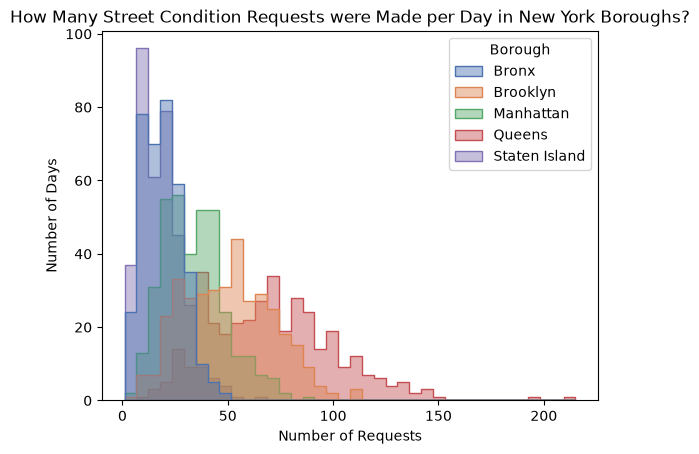

In [15]:
# Write your code here.
sns.histplot(data=daily_requests,
             x="request_count",
             hue="borough",
             hue_order=borough_order,
             element="step",
             multiple="layer",
             alpha=0.45,
             palette="deep"
)
plt.gca().get_legend().set_title("Borough")
plt.ylabel("Number of Days")
plt.xlabel("Number of Requests")
plt.title("How Many Street Condition Requests were Made per Day in New York Boroughs?")
plt.show()

**What does the histogram reveal, and what makes the boroughs easy or difficult to compare?**

Your answer: It reveals roughly where the mean number of requests is.
Near the bottom left of the graph, it becomes extrenely difficult to differentiate between the Boroughs.


### Create a box plot

Put `request_count` on the x-axis and `borough` on the y-axis. Use `borough_order`, the named color `"mediumseagreen"`, and descriptive labels.


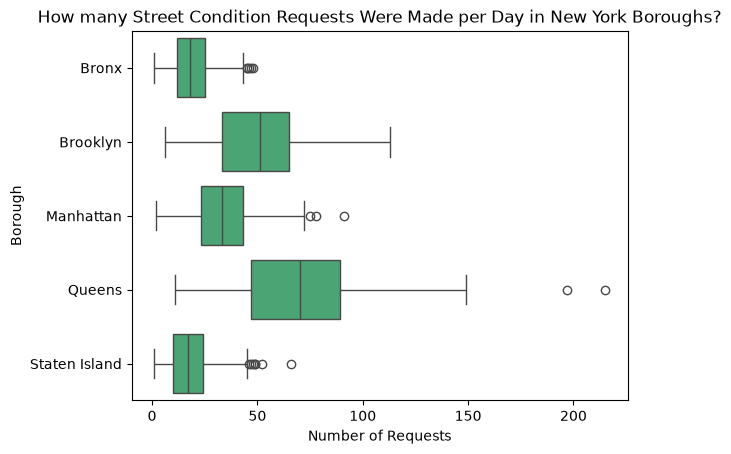

In [16]:
# Write your code here.
sns.boxplot(
    data=daily_requests,
    x="request_count",
    y="borough",
    color="mediumseagreen",
    order=borough_order
)
plt.title("How many Street Condition Requests Were Made per Day in New York Boroughs?")
plt.ylabel("Borough")
plt.xlabel("Number of Requests")
plt.show()

**What differences among boroughs are easier to see in the box plot than in the histogram?**

Your answer: It becomes much easier to see the max and minimum values, as well as the location of each Quartile and outlier 


### Create a violin plot

Use the same x feature, y feature, and order. Change only the plot color to `"mediumpurple"` in addition to the required data mappings and order.


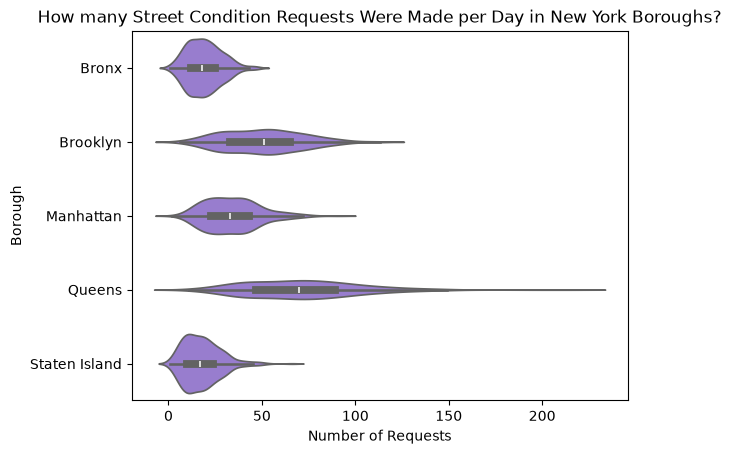

In [17]:
# Write your code here.
sns.violinplot(
    data=daily_requests,
    x="request_count",
    y="borough",
    color="mediumpurple",
    order=borough_order
)
plt.title("How many Street Condition Requests Were Made per Day in New York Boroughs?")
plt.ylabel("Borough")
plt.xlabel("Number of Requests")
plt.show()

**What does the violin plot add to the comparison?**

Your answer: It uses the height of each plot to display how many times that value occured.


**Which of the three figures most clearly compares daily request counts among boroughs? Explain your choice.**

Your answer: The box plot is the best at comparing the number of daily requests per borough because you can clearly see which parts of the graph belong to each borough. I would argue the Violin plot could be better, but not many people are familiar with how it works.


## Step 6: Conclusion


**What conclusion about borough differences is supported by the 2025 data?**

Your answer: Queens tends to have the highest number of requests per day, while Staten Island and Bronx tend to have the least.


## Step 7: Limitation


**Why do these request counts not directly measure the number of street problems or borough performance?**

Your answer: These graphs do not account for the size or population of each borough. (Staten Island's Population is ~1/4th the size of Queens, and has ~1/3 the square milage)


# Your own analysis

Develop a new research question using the 311 data. Your question must compare a **quantitative feature across categorical groups**. You will probably need to calculate the quantitative feature from the original request records.

Possible grouping features include `descriptor`, month, or day of the week. You may use another meaningful categorical feature that you can create and explain.


## Step 1: Question


**Write a research question that compares a quantitative feature across categorical groups.**

Your answer: Which Day of the Week gets the most Street Condition Requests in NYC?


## Step 2: Data


**Which original features will you use, and what will each row of your calculated DataFrame represent?**

Your answer:
Original Features: Day of the Week
Each row will represent the number of requests made on a specific day of the week

## Step 3: Operation

Prepare the grouping feature, calculate the quantitative feature, and save the resulting DataFrame with a meaningful name.


In [18]:
# Write your code here.
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
requests_df = requests.copy()
requests_df["weekday"] = requests_df["date"].dt.day_name()
requests_df.groupby("weekday").describe().reindex(day_order)

request_id                                                     \
               count          mean         min          25%         50%   
weekday                                                                   
Monday       11772.0  6.535045e+07  63647646.0  64514819.75  65278852.5   
Tuesday      12519.0  6.535081e+07  63647673.0  64465354.00  65237654.0   
Wednesday    12555.0  6.532750e+07  63575321.0  64474734.50  65237033.0   
Thursday     11602.0  6.527248e+07  63586867.0  64417217.25  65242013.5   
Friday        9550.0  6.537571e+07  63601375.0  64618762.00  65260986.5   
Saturday      5799.0  6.532767e+07  63615170.0  64504382.50  65214422.0   
Sunday        6401.0  6.532809e+07  63632045.0  64445955.00  65218875.0   

                                                 created_date  \
                   75%         max           std        count   
weekday                                                         
Monday     66161587.75  67401512.0  1.019799e+06        11772   
Tuesday    66104885.50  67390812.0  1.018234e+06        12519   
Wednesday  66111765.50  67353615.0  1.009036e+06        12555   
Thursday   66044611.75  67305678.0  9.941894e+05        11602   
Friday     66131340.50  67313769.0  9.679803e+05         9550   
Saturday   66072554.50  67343155.0  9.798007e+05         5799   
Sunday     66085892.00  67352852.0  1.034619e+06         6401   

                                       ...                             date  \
                                 mean  ...                  max  std  count   
weekday                                ...                                    
Monday     2025-06-22 10:39:06.546466  ...  2025-12-29 23:46:47  NaN  11772   
Tuesday    2025-06-22 10:42:33.567457  ...  2025-12-30 23:57:23  NaN  12519   
Wednesday  2025-06-20 03:24:34.951413  ...  2025-12-31 23:39:14  NaN  12555   
Thursday   2025-06-14 17:50:42.657041  ...  2025-12-25 22:11:23  NaN  11602   
Friday     2025-06-25 04:15:23.955497  ...  2025-12-26 23:25:25  NaN   9550   
Saturday   2025-06-20 04:43:41.325401  ...  2025-12-27 23:50:09  NaN   5799   
Sunday     2025-06-20 00:33:04.106858  ...  2025-12-28 23:47:33  NaN   6401   

                                                            \
                                 mean                  min   
weekday                                                      
Monday     2025-06-21 21:15:21.100917  2025-01-06 00:00:00   
Tuesday    2025-06-21 21:22:04.227174  2025-01-07 00:00:00   
Wednesday  2025-06-19 14:15:23.870967  2025-01-01 00:00:00   
Thursday   2025-06-14 04:40:45.095673  2025-01-02 00:00:00   
Friday     2025-06-24 14:53:51.329843  2025-01-03 00:00:00   
Saturday   2025-06-19 14:27:07.728918  2025-01-04 00:00:00   
Sunday     2025-06-19 10:27:12.119981  2025-01-05 00:00:00   

                                                                          \
                           25%                  50%                  75%   
weekday                                                                    
Monday     2025-03-31 00:00:00  2025-06-16 00:00:00  2025-09-15 00:00:00   
Tuesday    2025-03-25 00:00:00  2025-06-10 00:00:00  2025-09-09 00:00:00   
Wednesday  2025-03-26 00:00:00  2025-06-11 00:00:00  2025-09-10 00:00:00   
Thursday   2025-03-20 00:00:00  2025-06-12 00:00:00  2025-09-04 00:00:00   
Friday     2025-04-11 00:00:00  2025-06-13 00:00:00  2025-09-12 00:00:00   
Saturday   2025-03-29 00:00:00  2025-06-07 00:00:00  2025-09-06 00:00:00   
Sunday     2025-03-23 00:00:00  2025-06-08 00:00:00  2025-09-07 00:00:00   

                                     
                           max  std  
weekday                              
Monday     2025-12-29 00:00:00  NaN  
Tuesday    2025-12-30 00:00:00  NaN  
Wednesday  2025-12-31 00:00:00  NaN  
Thursday   2025-12-25 00:00:00  NaN  
Friday     2025-12-26 00:00:00  NaN  
Saturday   2025-12-27 00:00:00  NaN  
Sunday     2025-12-28 00:00:00  NaN  

[7 rows x 24 columns]

In [19]:
weekday_requests = requests_df.groupby(["weekday", "date"]).size().reset_index(name="request_count")
#daily_requests = requests.groupby(["borough", "date"]).size().reset_index(name="request_count")
weekday_requests
weekday_requests

,weekday,date,request_count
0,Friday,2025-01-03,136
1,Friday,2025-01-10,133
2,Friday,2025-01-17,121
3,Friday,2025-01-24,111
4,Friday,2025-01-31,119
...,...,...,...
360,Wednesday,2025-12-03,241
361,Wednesday,2025-12-10,204
362,Wednesday,2025-12-17,182
363,Wednesday,2025-12-24,104


**Briefly explain how your code produced the quantitative feature and comparison groups.**

Your answer: To get the comparison groups, I extracted the day of the week from the exsiting datetime using `.dt.day_name()`.
Then, to get the number of requests on each day, I simply checked for the number of times each weekday occured.


## Step 4: Check

Check the calculated data for missing or impossible values, confirm that the intended groups are present, and use an appropriate numerical summary to inspect the distributions.


In [20]:
# Write your code here.
#checking that the expected total number of requests matches the total number
bool(weekday_requests["request_count"].sum() == requests["request_id"].count())


True

In [21]:
weekday_requests[["weekday", "request_count"]].groupby("weekday").describe().reindex(day_order)

request_count                                                       \
                  count        mean        std    min     25%    50%     75%   
weekday                                                                        
Monday             52.0  226.384615  58.222748   96.0  194.75  217.0  258.00   
Tuesday            52.0  240.750000  53.614775  101.0  208.50  243.0  274.25   
Wednesday          53.0  236.886792  57.224477  104.0  194.00  234.0  274.00   
Thursday           52.0  223.115385  56.400756   40.0  192.75  216.0  265.25   
Friday             52.0  183.653846  55.178457   63.0  144.00  177.5  217.25   
Saturday           52.0  111.519231  28.413260   60.0   91.75  110.0  128.25   
Sunday             52.0  123.096154  29.658355   57.0  104.75  124.0  146.25   

                  
             max  
weekday           
Monday     408.0  
Tuesday    362.0  
Wednesday  426.0  
Thursday   330.0  
Friday     308.0  
Saturday   178.0  
Sunday     186.0

**What did your checks establish?**

Your answer:
1. The number of expected requests matches the total number of requests.
2. No days had <0 requests


## Step 5: Evidence

Create a histogram, box plot, or violin plot that directly addresses your question. Include a clear title and descriptive axis labels.


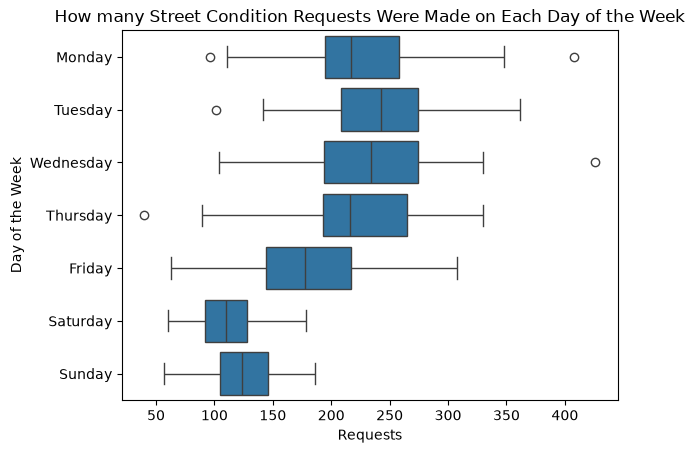

In [22]:
# Write your code here.
sns.boxplot(
    data=weekday_requests,
    x="request_count",
    y="weekday",
    order=day_order
)
plt.title("How many Street Condition Requests Were Made on Each Day of the Week")
plt.xlabel("Requests")
plt.ylabel("Day of the Week")
plt.show()

**What pattern in the figure provides the strongest evidence for your answer?**

Your answer: The medians.


## Step 6: Conclusion


**State one conclusion that directly answers your research question.**

Your answer:
Tuesdays tend to have the highest amount of Street Condition Requests, while Saturdays and Sundays tend to have the least.

## Step 7: Limitation


**State one important limitation on how your result should be interpreted.**

Your answer: The data for this study is only from 2025 in New York City.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that clearly.

Your answer: I did not use an AI tool.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object and feature names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Compare center, spread, shape, overlap, and unusual values.
- Distinguish reported request volume from actual street conditions or city performance.
- Complete the AI-use reflection.
